### Fuzzy SVM. 
Użyj go do rozwiązania wybranego problemu klasyfikacji. Porównaj wyniki z klasycznym SVM.

**importy**

In [7]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

**Fuzzy SVM - własna interpretacja**

In [8]:
class FuzzySVM:
    def __init__(self, C=1.0, kernel="poly"):
        self._model = SVC(kernel=kernel)

    def _compute_memberships(self, X, y):
        
        memberships = np.zeros(len(X))
        classes = np.unique(y)

        MIN_WEIGHT = 0.1  
        MAX_WEIGHT = 1.0  

        for cls in classes:
            indexes_in_class = np.where(y == cls)[0]     
            X_in_class = X[indexes_in_class]                  
            center_of_class = X_in_class.mean(axis=0)     

            dist = np.linalg.norm(X_in_class - center_of_class, axis=1)

            if dist.max() == 0:
                norm_dist = np.zeros_like(dist)
            else:
                norm_dist = dist / dist.max()

            m = MAX_WEIGHT - norm_dist * (MAX_WEIGHT - MIN_WEIGHT)

            memberships[indexes_in_class] = m
        return memberships

    def fit(self, X, y):
        memberships = self._compute_memberships(X, y)
        self._model.fit(X, y, sample_weight=memberships)
        return self

    def predict(self, X):
        return self._model.predict(X)
    
    def score(self, X, y):
        return self._model.score(X, y)


**test**


Dataset size: 2x2
Sklearn SVM, Accuracy: 0.96


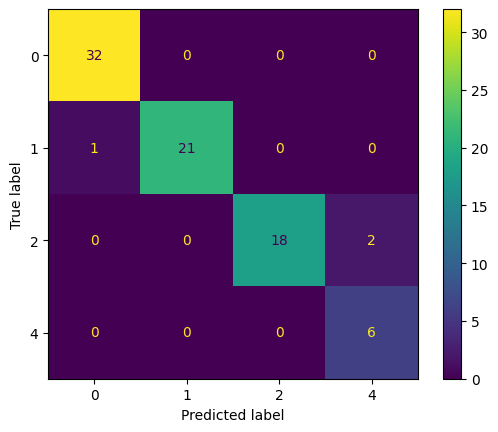

Fuzzy SVM, Accuracy: 0.95


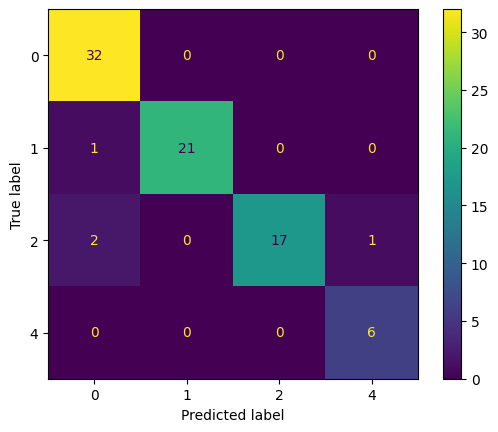


Dataset size: 3x3
Sklearn SVM, Accuracy: 0.94


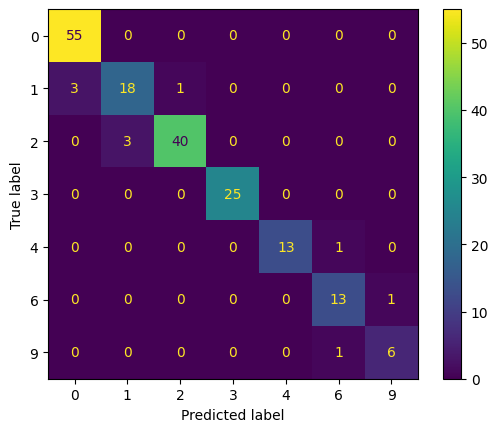

Fuzzy SVM, Accuracy: 0.93


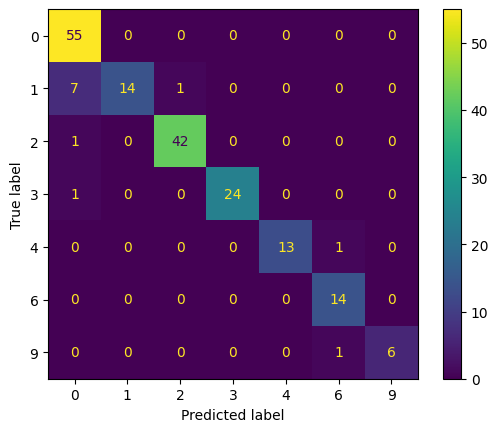


Dataset size: 4x4
Sklearn SVM, Accuracy: 0.82


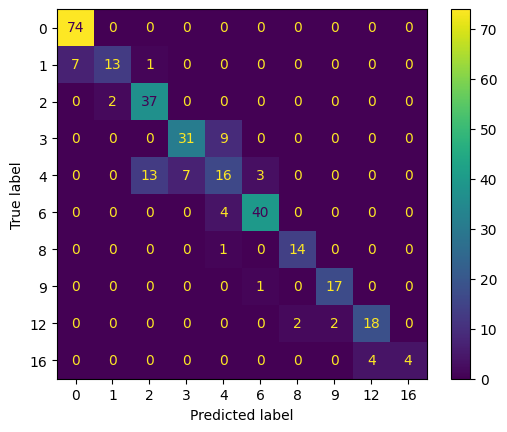

Fuzzy SVM, Accuracy: 0.75


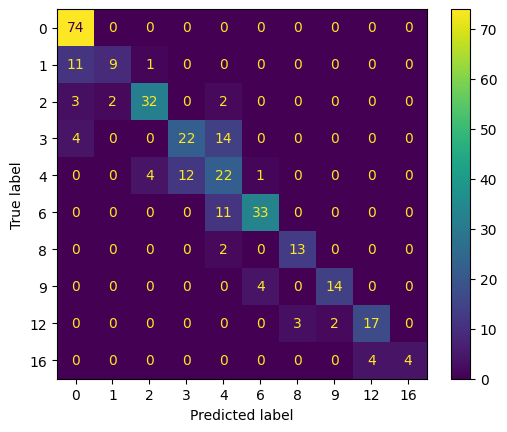

In [9]:
def custom_round(val):
    return int(val + 0.5)

sizes = [2, 3, 4]

for size in sizes:
    print(f'\nDataset size: {size}x{size}')
    x = np.arange(0, size, 0.1)
    x,y = np.meshgrid(x, x)

    dataX = x.flatten()
    dataY = y.flatten()
    dataXY = np.column_stack((dataX,dataY))   

    data_labels = [custom_round(a) * custom_round(b) for a, b in dataXY]

    X_train, X_test, y_train, y_test = train_test_split(dataXY, data_labels, test_size=0.2, random_state=25)

    ready_svm = SVC(kernel='poly')
    ready_svm.fit(X_train, y_train)
    print(f'Sklearn SVM, Accuracy: {ready_svm.score(X_test, y_test):.2f}')
    ConfusionMatrixDisplay.from_predictions(y_test, ready_svm.predict(X_test))
    plt.show()

    fuzzy_svm = FuzzySVM(kernel='poly')
    fuzzy_svm.fit(X_train, y_train)
    print(f'Fuzzy SVM, Accuracy: {fuzzy_svm.score(X_test, y_test):.2f}')
    ConfusionMatrixDisplay.from_predictions(y_test, fuzzy_svm.predict(X_test))
    plt.show()